# Project Passengers: Time Series Forecasting with Keras

This document outlines a time series forecasting project using Keras. It covers data loading, preprocessing, model creation (both linear and non-linear regression), training, and evaluation.

## 1\. Data Loading and Initial Analysis

The first step is to load the necessary libraries and the dataset.

In [151]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib as mpl

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error

from keras.models import Sequential
from keras.layers import Dense, Input, LSTM, Dropout, GRU
from keras.optimizers import Adam


### Loading the Dataset

The dataset, named 'Passageiros.csv', is loaded into a pandas DataFrame.

In [33]:
passageiros = pd.read_csv('Passageiros.csv')

### Initial Data Exploration

A quick look at the first few rows of the dataset to understand its structure.

In [34]:
passageiros.head()

,tempo,passageiros
0,1949.000000,112
1,1949.083333,118
2,1949.166667,132
3,1949.250000,129
4,1949.333333,121


### Visualization Setup

Setting up the plot aesthetics for better visualization of the data.

In [35]:
mpl.rcParams['figure.figsize'] = (10, 6)
mpl.rcParams['font.size'] = 22

### Time Series Visualization

Visualizing the complete time series data to observe trends and patterns.

<Axes: xlabel='tempo', ylabel='passageiros'>

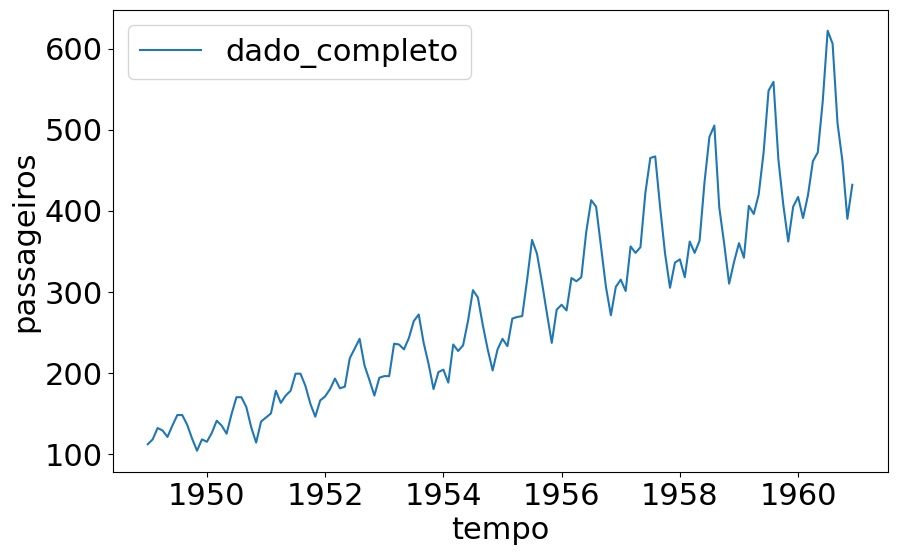

In [36]:
sns.lineplot(x='tempo',y='passageiros', data=passageiros,label='dado_completo') 

## 2\. Data Scaling

To prepare the data for the neural network, we scale it using `StandardScaler`. This is a crucial step to ensure that all features have the same scale, which helps in the convergence of the model.

In [37]:
sc = StandardScaler()
sc.fit(passageiros)
dado_escalado = sc.transform(passageiros)

### Feature and Target Separation

The scaled data is then separated into features (x) and the target (y). In this case, 'tempo' (time) is the feature and 'passageiros' (passengers) is the target variable.

In [38]:
x=dado_escalado[:,0] 
y=dado_escalado[:,1] 

### Scaled Data Visualization

Visualizing the scaled data to confirm the transformation.

Text(0.5, 0, 'Data')

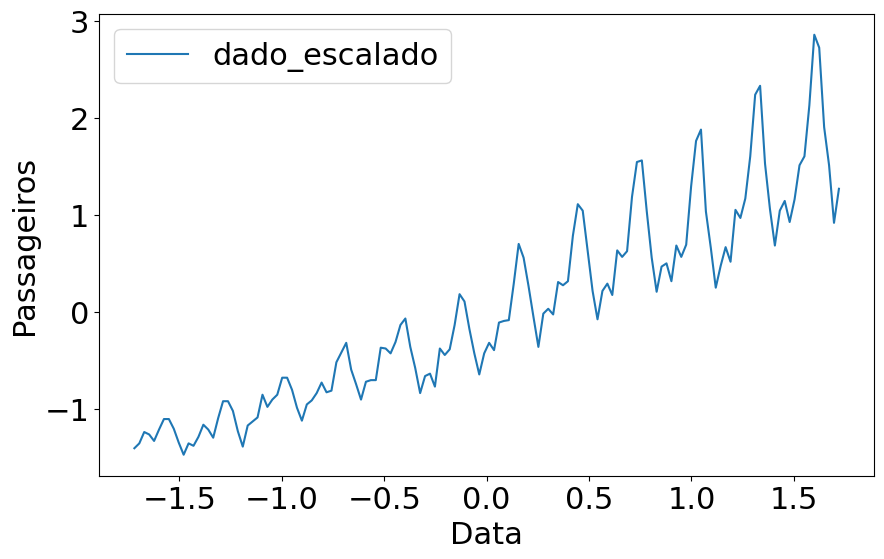

In [39]:
sns.lineplot(x=x,y=y,label='dado_escalado') 
plt.ylabel('Passageiros')
plt.xlabel('Data')

## 3\. Splitting into Training and Test Sets

The dataset is split into training (90%) and testing (10%) sets. This is a standard practice to evaluate the model's performance on unseen data.

In [40]:
tamanho_treino = int(len(passageiros)*0.9) 
tamanho_teste = len(passageiros)-tamanho_treino 

In [41]:
xtreino = x[0:tamanho_treino]
ytreino = y[0:tamanho_treino]

In [42]:
xteste = x[tamanho_treino:len(passageiros)]
yteste = y[tamanho_treino:len(passageiros)]

### Visualizing the Data Splits

Visualizing the training and test splits to ensure they are correctly divided.

<Axes: >

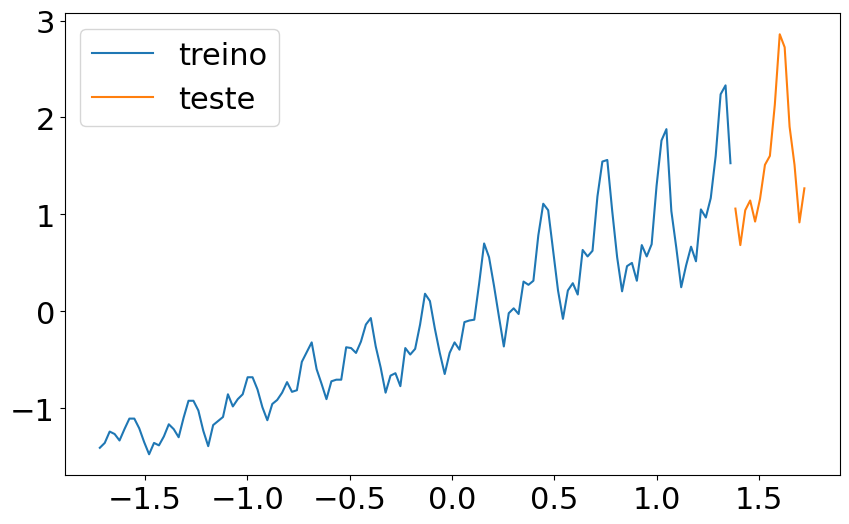

In [43]:
sns.lineplot(x=xtreino,y=ytreino,label='treino') 
sns.lineplot(x=xteste,y=yteste,label='teste') 

## 4\. Linear Regression Model

A simple linear regression model is built using Keras as a baseline for our time series forecast.

### Model Definition

The model is a `Sequential` model with a single `Dense` layer. The `kernel_initializer` is set to 'Ones' for reproducibility, and the activation is 'linear' as we are performing a regression task

In [44]:
regressor = Sequential()

# Input Layer
regressor.add(Input(shape=(1,)))

# Dense Layer
regressor.add(Dense(1, kernel_initializer='Ones', 
                    activation='linear', use_bias=False))

### Model Compilation and Summary

The model is compiled with the 'mean\_squared\_error' loss function and the 'adam' optimizer. A summary of the model architecture is also printed.

In [45]:
regressor.compile(loss='mean_squared_error',optimizer='adam')

regressor.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_7 (Dense)                 │ (None, 1)              │             1 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1 (4.00 B)

 Trainable params: 1 (4.00 B)

 Non-trainable params: 0 (0.00 B)

### Model Training and Prediction

The model is trained on the training data, and then used to predict the values for the same training data to see how well it fits.

In [46]:
regressor.fit(xtreino,ytreino)

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1284  


In [47]:
y_predict= regressor.predict(xtreino) #Prevendo os dados de treino (o ajuste)

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 


### Visualization of Training Results

The training data is plotted against the model's predictions to visually assess the fit.

<Axes: >

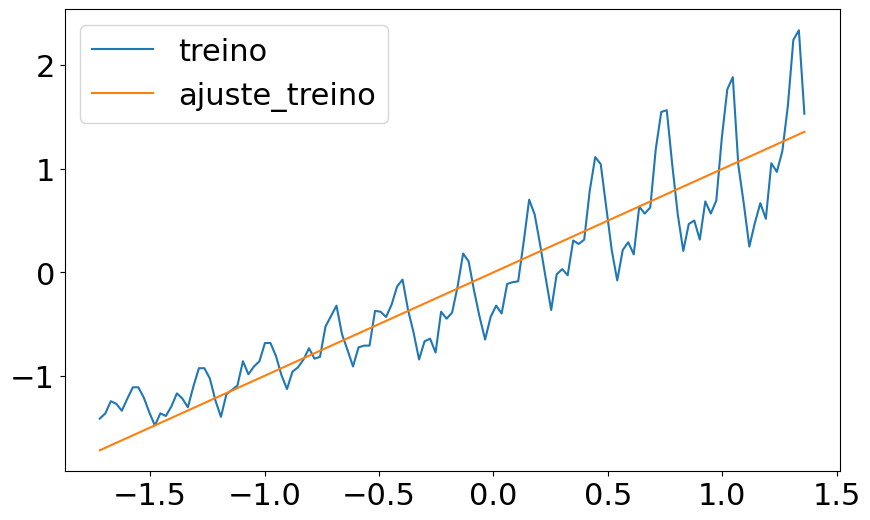

In [48]:
sns.lineplot(x=xtreino,y=ytreino,label='treino')
sns.lineplot(x=xtreino,y=y_predict[:,0],label='ajuste_treino')

### Inverse Transform Results

The results are inverse-transformed to be interpreted in the original scale, allowing for a more intuitive understanding of the model's performance.

In [49]:
d = {'tempo': xtreino, 'passageiros': y_predict[:,0]}
resultados = pd.DataFrame(data=d)
resultados

,tempo,passageiros
0,-1.720064,-1.712912
1,-1.696007,-1.688955
2,-1.671950,-1.664998
3,-1.647894,-1.641041
4,-1.623837,-1.617084
...,...,...
124,1.262984,1.257732
125,1.287041,1.281689
126,1.311098,1.305646
127,1.335155,1.329603


In [50]:
resultado_transf = sc.inverse_transform(resultados)

resultado_transf = pd.DataFrame(resultado_transf)

resultado_transf.columns = ['tempo','passageiros']

### Visualizing the Fitted Model

Visualizing the fitted model against the original data to understand its performance in the original context.

<Axes: xlabel='tempo', ylabel='passageiros'>

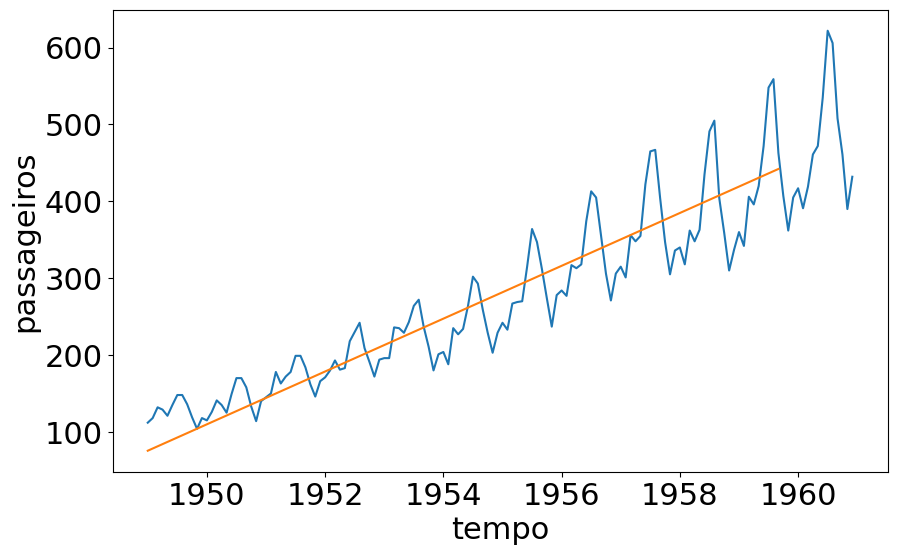

In [51]:
sns.lineplot(x="tempo",y="passageiros",data=passageiros)
sns.lineplot(x="tempo",y="passageiros",data=resultado_transf)

### Prediction on the Test Set

The trained model is now used to make predictions on the test set.

In [52]:
y_predict_teste= regressor.predict(xteste)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step


In [53]:
d = {'tempo': xteste, 'passageiros': y_predict_teste[:,0]}

resultados_teste = pd.DataFrame(data=d)
resultado_transf_teste = sc.inverse_transform(resultados_teste)
resultado_transf_teste = pd.DataFrame(resultado_transf_teste)
resultado_transf_teste.columns = ['tempo','passageiros']

### Final Visualization with Forecast

Visualizing the complete data, the training fit, and the forecast on the test data.

<Axes: xlabel='tempo', ylabel='passageiros'>

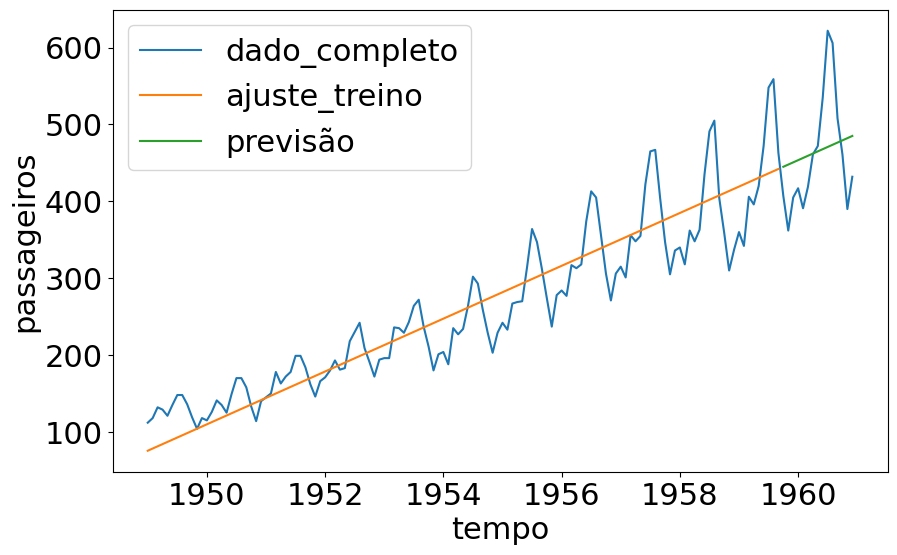

In [54]:
sns.lineplot(x="tempo",y="passageiros",data=passageiros,label='dado_completo')
sns.lineplot(x="tempo",y="passageiros",data=resultado_transf,label='ajuste_treino')
sns.lineplot(x="tempo",y="passageiros",data=resultado_transf_teste,label='previsão')

In [55]:
# Definir o modelo
regressor2 = Sequential()
regressor2.add(Input(shape=(1,)))  # entrada de 1 dimensão

regressor2.add(Dense(units=8, kernel_initializer='random_uniform', activation='linear', use_bias=False))
regressor2.add(Dense(units=8, kernel_initializer='random_uniform', activation='linear', use_bias=False))
regressor2.add(Dense(units=1, kernel_initializer='random_uniform', activation='linear', use_bias=False))


In [56]:
regressor2.compile(optimizer='adam', loss='mean_squared_error')
regressor2.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_8 (Dense)                 │ (None, 8)              │             8 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 8)              │            64 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 1)              │             8 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 80 (320.00 B)

 Trainable params: 80 (320.00 B)

 Non-trainable params: 0 (0.00 B)

In [57]:
regressor2.fit(xtreino, ytreino, epochs=200)

Epoch 1/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.8092  
Epoch 2/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.8085 
Epoch 3/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.8075 
Epoch 4/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.8062 
Epoch 5/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.8043 
Epoch 6/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.8017 
Epoch 7/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.7984 
Epoch 8/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.7935 
Epoch 9/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.7875 
Epoch 10/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.7800 
Epoch 11/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.7696 
Epoch 12/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.7573 
Epoch 13/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.7418 
Epoch 14/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.7250 
Epoch 15/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.7049 
Epoch 16/200
5/5 ━

In [58]:
y_predict = regressor2.predict(xtreino)

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step


In [59]:
y_predict_teste = regressor2.predict(xteste)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step


<Axes: >

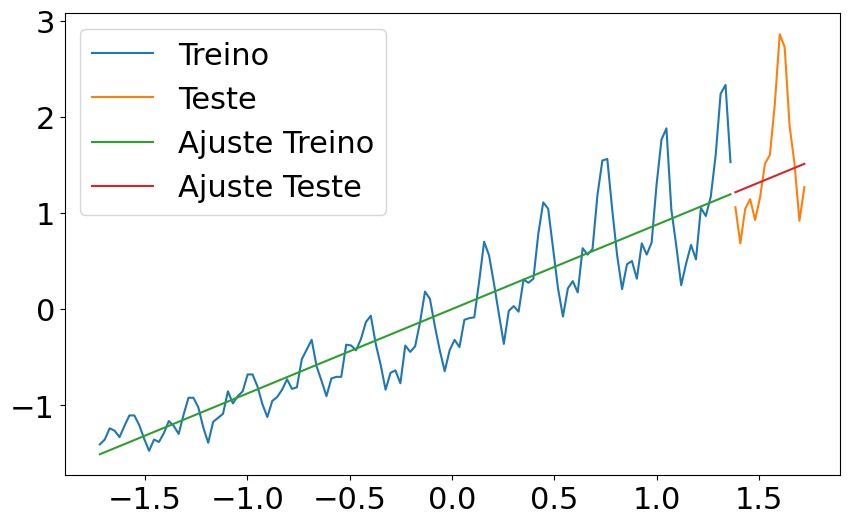

In [60]:
sns.lineplot(x=xtreino, y=ytreino, label='Treino')
sns.lineplot(x=xteste, y=yteste, label='Teste')
sns.lineplot(x=xtreino, y=y_predict[:,0], label='Ajuste Treino')
sns.lineplot(x=xteste, y=y_predict_teste[:,0], label='Ajuste Teste')

## 5\. Non-linear Regression Model

To capture more complex patterns in the data, a non-linear model with multiple dense layers and non-linear activation functions is implemented.

### Model Definition

This is a `Sequential` model with three `Dense` layers. The first two layers use the 'sigmoid' activation function to introduce non-linearity, while the final layer uses a 'linear' activation for the regression output.

In [61]:
regressor2 = Sequential([
    Input(shape=(1,)),  
    Dense(8, kernel_initializer='random_uniform', activation='sigmoid', use_bias=False),
    Dense(8, kernel_initializer='random_uniform', activation='sigmoid', use_bias=False),
    Dense(1, kernel_initializer='random_uniform', activation='linear', use_bias=False)
])

regressor2.summary()


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_11 (Dense)                │ (None, 8)              │             8 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 8)              │            64 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 1)              │             8 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 80 (320.00 B)

 Trainable params: 80 (320.00 B)

 Non-trainable params: 0 (0.00 B)

### Model Compilation and Training

The model is compiled with 'mean\_squared\_error' as the loss function and 'adam' as the optimizer. It is then trained for 500 epochs to allow it to learn the non-linear relationships in the data.

In [62]:
regressor2.compile(loss='mean_squared_error',optimizer='adam')
regressor2.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_11 (Dense)                │ (None, 8)              │             8 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 8)              │            64 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 1)              │             8 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 80 (320.00 B)

 Trainable params: 80 (320.00 B)

 Non-trainable params: 0 (0.00 B)

In [63]:
regressor2.fit(xtreino,ytreino,epochs =500)

Epoch 1/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.8130  
Epoch 2/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.8065 
Epoch 3/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.8016 
Epoch 4/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.7978 
Epoch 5/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.7936 
Epoch 6/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.7902 
Epoch 7/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.7882 
Epoch 8/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.7854 
Epoch 9/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.7850 
Epoch 10/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.7833 
Epoch 11/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.7837 
Epoch 12/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.7841 
Epoch 13/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.7843 
Epoch 14/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.7841 
Epoch 15/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.7832 
Epoch 16/500
5/5 ━

### Prediction and Visualization

The trained non-linear model is used to predict on both the training and test sets.

In [64]:
y_predict= regressor2.predict(xtreino)

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 


In [65]:
y_predict_teste= regressor2.predict(xteste)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step


<Axes: >

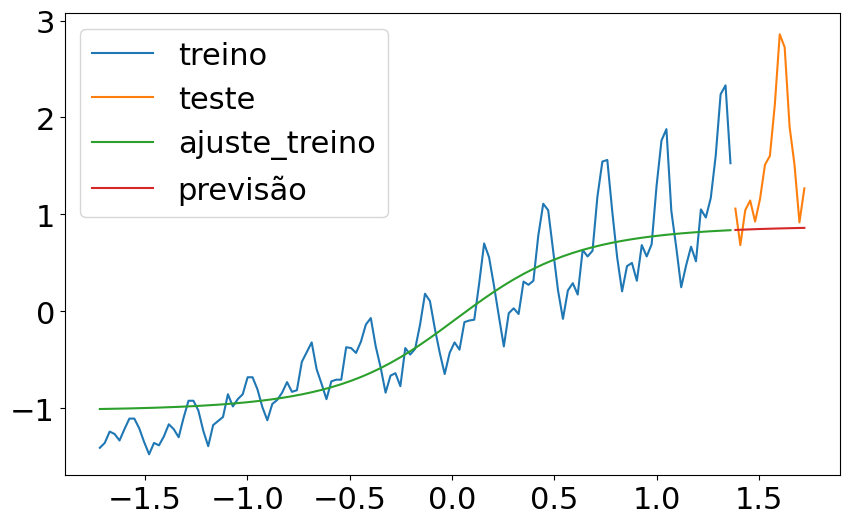

In [66]:
sns.lineplot(x=xtreino,y=ytreino,label='treino')
sns.lineplot(x=xteste,y=yteste,label='teste')
sns.lineplot(x=xtreino,y=y_predict[:,0],label='ajuste_treino')
sns.lineplot(x=xteste,y=y_predict_teste[:,0],label='previsão')

In [67]:
vetor = pd.DataFrame(ytreino)[0]

## 6\. Long Short-Term Memory (LSTM) Model

Now, we will use a more advanced model for time series forecasting: the Long Short-Term Memory (LSTM) network. LSTMs are a type of recurrent neural network (RNN) that are well-suited for learning from sequential data.

### Data Preparation for LSTM

LSTMs require the input data to be in a specific format: a 3D array with dimensions `[samples, time steps, features]`. In this context:
- **Samples**: The number of data sequences.
- **Time Steps**: The number of past time steps used to predict the next value.
- **Features**: The number of variables at each time step (univariate time series have one feature).

The following code prepares the data for the LSTM model by creating sequences of past observations (time steps) to predict the next value in the series.

In [68]:
# Prepare data for LSTM
def separa_dados(vetor,n_passos):
  X_novo, y_novo = [], []
  for i in range(n_passos,vetor.shape[0]):
    X_novo.append(list(vetor.loc[i-n_passos:i-1]))
    y_novo.append(vetor.loc[i])
  X_novo, y_novo = np.array(X_novo), np.array(y_novo) 
  return X_novo, y_novo

### Data Splitting
- **Training Data**: `xtreino_novo, ytreino_novo = separa_dados(vetor, 1)`
- **Test Data**: `xteste_novo, yteste_novo = separa_dados(vetor2, 1)`
- **Note**: Using `n_passos = 1` creates simple one-step lookback sequences

In [69]:
xtreino_novo, ytreino_novo = separa_dados(vetor,1)

In [70]:
xtreino_novo[0:5] #X

array([[-1.40777884],
       [-1.35759023],
       [-1.24048348],
       [-1.26557778],
       [-1.33249593]])

In [71]:
ytreino_novo[0:5]

array([-1.35759023, -1.24048348, -1.26557778, -1.33249593, -1.21538918])

In [72]:
vetor2 = pd.DataFrame(yteste)[0]

In [73]:
xteste_novo, yteste_novo = separa_dados(vetor2,1)

## Model Architecture

### Sequential Model Structure

### Layer Details
1. **Input Layer**: Single feature input
2. **First Hidden Layer**: 
   - 8 neurons
   - Linear activation
   - Ones initialization
   - No bias
3. **Second Hidden Layer**:
   - 64 neurons  
   - Sigmoid activation
   - Random uniform initialization
   - No bias
4. **Output Layer**:
   - 1 neuron (single value prediction)
   - Linear activation
   - Random uniform initialization
   - No bias

In [74]:
regressor3 = Sequential()

regressor3.add(Input(shape=(1,)))  # Define a camada de entrada

regressor3.add(Dense(8, kernel_initializer='ones', activation='linear', use_bias=False))
regressor3.add(Dense(64, kernel_initializer='random_uniform', activation='sigmoid', use_bias=False))
regressor3.add(Dense(1, kernel_initializer='random_uniform', activation='linear', use_bias=False))

regressor3.compile(loss='mean_squared_error', optimizer='adam')
regressor3.summary()


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_14 (Dense)                │ (None, 8)              │             8 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 64)             │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 1)              │            64 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 584 (2.28 KB)

 Trainable params: 584 (2.28 KB)

 Non-trainable params: 0 (0.00 B)

### Model Configuration
- **Epochs**: 100 training iterations
- **Batch Size**: Default (not specified)
- **Loss Progression**: Decreased from ~0.77 to ~0.0625

In [75]:
regressor3.fit(xtreino_novo,ytreino_novo,epochs =100)

Epoch 1/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.8001  
Epoch 2/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.7584 
Epoch 3/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.7304 
Epoch 4/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.7108 
Epoch 5/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.6922 
Epoch 6/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.6692 
Epoch 7/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.6459 
Epoch 8/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.6215 
Epoch 9/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.5907 
Epoch 10/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.5606 
Epoch 11/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.5272 
Epoch 12/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.4916 
Epoch 13/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.4524 
Epoch 14/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.4135 
Epoch 15/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.3697 
Epoch 16/100
4/4 ━

## Model Evaluation
- Generates predictions on training data
- Used for model performance assessment

In [76]:
y_predict_novo = regressor3.predict(xtreino_novo)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 


<Axes: xlabel='tempo', ylabel='0'>

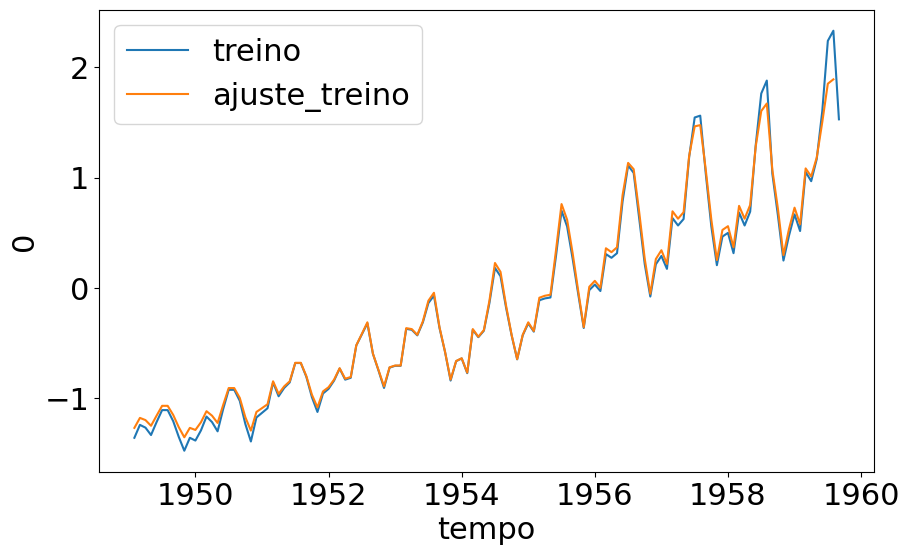

In [77]:
sns.lineplot(x='tempo',y=ytreino_novo,data=passageiros[1:129],label='treino')
sns.lineplot(x='tempo',y=pd.DataFrame(y_predict_novo)[0],data=passageiros[1:129],label='ajuste_treino')

In [78]:
y_predict_teste_novo = regressor3.predict(xteste_novo)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step


In [79]:
resultado = pd.DataFrame(y_predict_teste_novo)[0]

### Visualizing Training Fit and Test Forecast

This final visualization brings together the model's performance on both the training and test datasets, plotting them against the original timeline.

  - **Training Data vs. Model Fit**: The first two lines plot the actual training data (`treino`) against the model's predictions for that same period (`ajuste_treino`). This allows us to visually inspect how well the model has learned the patterns in the training data.
  - **Test Data vs. Forecast**: The next two lines show the actual, unseen test data (`teste`) plotted against the model's forecasts for that period (`previsão`). This is the true measure of the model's predictive power and its ability to generalize to new data.

<Axes: xlabel='tempo', ylabel='0'>

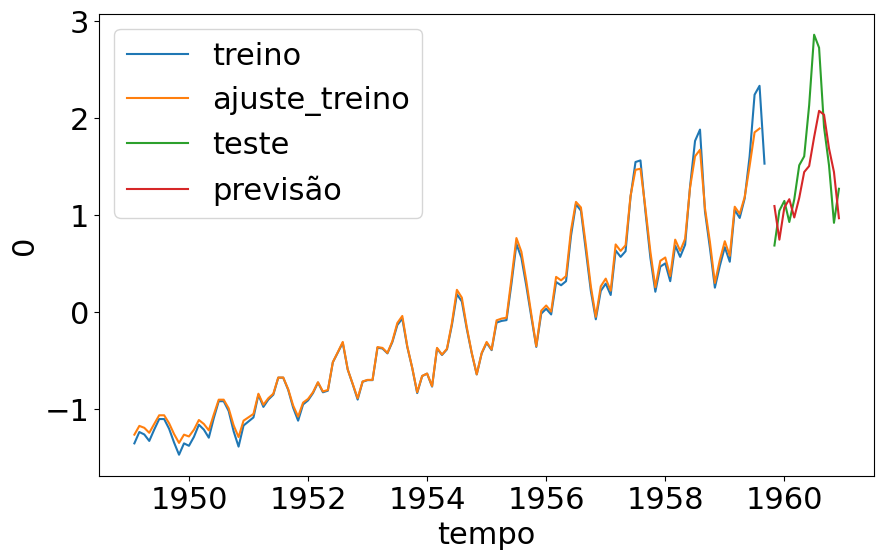

In [80]:
sns.lineplot(x='tempo',y=ytreino_novo,data=passageiros[1:129],label='treino')
sns.lineplot(x='tempo',y=pd.DataFrame(y_predict_novo)[0],data=passageiros[1:129],label='ajuste_treino')

sns.lineplot(x='tempo',y=yteste_novo,data=passageiros[130:144],label='teste')
sns.lineplot(x='tempo',y=resultado.values,data=passageiros[130:144],label='previsão')

In [81]:
xtreino_novo, ytreino_novo = separa_dados(vetor,4)

In [82]:
xtreino_novo[0:5] #X

array([[-1.40777884, -1.35759023, -1.24048348, -1.26557778],
       [-1.35759023, -1.24048348, -1.26557778, -1.33249593],
       [-1.24048348, -1.26557778, -1.33249593, -1.21538918],
       [-1.26557778, -1.33249593, -1.21538918, -1.10664719],
       [-1.33249593, -1.21538918, -1.10664719, -1.10664719]])

In [83]:
ytreino_novo[0:5] #y

array([-1.33249593, -1.21538918, -1.10664719, -1.10664719, -1.20702441])

In [84]:
xteste_novo, yteste_novo = separa_dados(vetor2,4)

### Neural Network Model for Regression

This block of code defines, compiles, and summarizes a feedforward neural network using the Keras `Sequential` API. This specific architecture is designed for a regression task where the input has four features.

In [85]:
regressor4 = Sequential()
regressor4.add(Input(shape=(4,)))  # entrada explícita

regressor4.add(Dense(8, kernel_initializer='random_uniform', activation='linear', use_bias=False))
regressor4.add(Dense(64, kernel_initializer='random_uniform', activation='sigmoid', use_bias=False))
regressor4.add(Dense(1, kernel_initializer='random_uniform', activation='linear', use_bias=False))

regressor4.compile(loss='mean_squared_error', optimizer='adam')
regressor4.summary()


Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_17 (Dense)                │ (None, 8)              │            32 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 64)             │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 1)              │            64 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 608 (2.38 KB)

 Trainable params: 608 (2.38 KB)

 Non-trainable params: 0 (0.00 B)

In [86]:
regressor4.fit(xtreino_novo,ytreino_novo,epochs =300)

Epoch 1/300
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.7896  
Epoch 2/300
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.7638 
Epoch 3/300
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.7603 
Epoch 4/300
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.7620 
Epoch 5/300
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.7589 
Epoch 6/300
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.7549 
Epoch 7/300
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.7515 
Epoch 8/300
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.7469 
Epoch 9/300
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.7434 
Epoch 10/300
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.7363 
Epoch 11/300
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.7280 
Epoch 12/300
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.7174 
Epoch 13/300
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.7068 
Epoch 14/300
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.6936 
Epoch 15/300
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.6791 
Epoch 16/300
4/4 ━

In [87]:
y_predict_teste_novo = regressor4.predict(xteste_novo)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step


In [88]:
resultado = pd.DataFrame(y_predict_teste_novo)[0]

### Visualization of Model Performance on Training and Test Sets

This code block generates a plot to visually evaluate the model's performance. It contrasts the model's predictions with the actual data for both the training and the previously unseen test periods.

  * **Training Fit Visualization**: The first pair of `sns.lineplot` calls display the original training data (`treino`) alongside the predictions the model made on that same data (`ajuste_treino`). This helps to assess how well the model has learned the underlying patterns of the training set.

  * **Forecast Visualization**: The second pair of calls plots the actual values from the test set (`teste`) against the forecasts generated by the model (`previsão`). This is a critical step to understand how the model generalizes and performs on new, unseen data.

<Axes: xlabel='tempo', ylabel='0'>

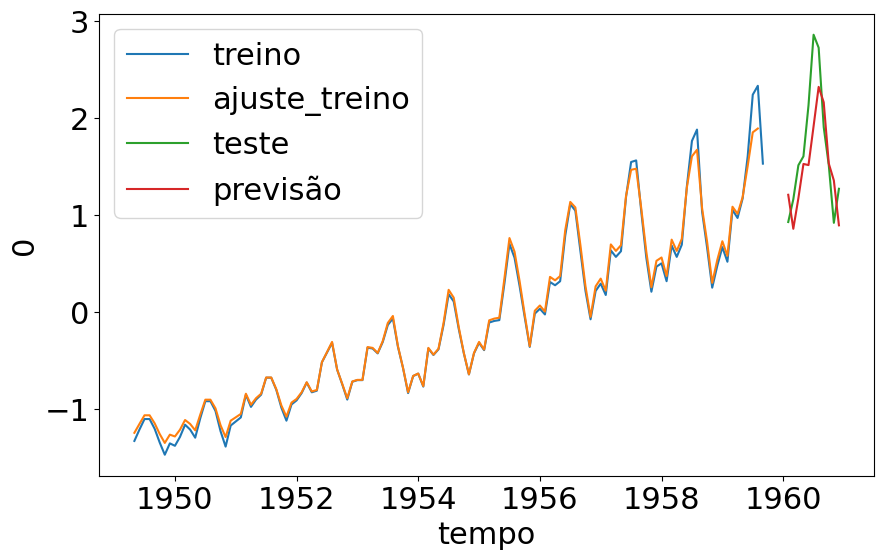

In [89]:
sns.lineplot(x='tempo',y=ytreino_novo,data=passageiros[4:129],label='treino')
sns.lineplot(x='tempo',y=pd.DataFrame(y_predict_novo)[0],data=passageiros[4:129],label='ajuste_treino')

sns.lineplot(x='tempo',y=yteste_novo,data=passageiros[133:144],label='teste')
sns.lineplot(x='tempo',y=resultado.values,data=passageiros[133:144],label='previsão')

# Project Bike: Time Series Forecasting with Keras

This document outlines a time series forecasting project using Keras. It covers data loading, preprocessing, model creation (both linear and non-linear regression), training, and evaluation.

## 2\. Data Loading and Initial Analysis

The first step is to load the necessary libraries and the dataset.

In [117]:
bike = pd.read_csv('bicicletas.csv')

In [118]:
bike.head()

,datas,contagem,temperatura,sensacao,umidade,vel_vento,clima,feriado,final_ds,estacao
0,2015-01-04 00:00:00,182,3.0,2.0,93.0,6.0,3.0,0.0,1.0,3.0
1,2015-01-04 01:00:00,138,3.0,2.5,93.0,5.0,1.0,0.0,1.0,3.0
2,2015-01-04 02:00:00,134,2.5,2.5,96.5,0.0,1.0,0.0,1.0,3.0
3,2015-01-04 03:00:00,72,2.0,2.0,100.0,0.0,1.0,0.0,1.0,3.0
4,2015-01-04 04:00:00,47,2.0,0.0,93.0,6.5,1.0,0.0,1.0,3.0


In [119]:
bike['datas'] = pd.to_datetime(bike['datas'])

(array([16436., 16526., 16617., 16709., 16801., 16892., 16983., 17075.,
        17167.]),
 [Text(16436.0, 0, '2015-01'),
  Text(16526.0, 0, '2015-04'),
  Text(16617.0, 0, '2015-07'),
  Text(16709.0, 0, '2015-10'),
  Text(16801.0, 0, '2016-01'),
  Text(16892.0, 0, '2016-04'),
  Text(16983.0, 0, '2016-07'),
  Text(17075.0, 0, '2016-10'),
  Text(17167.0, 0, '2017-01')])

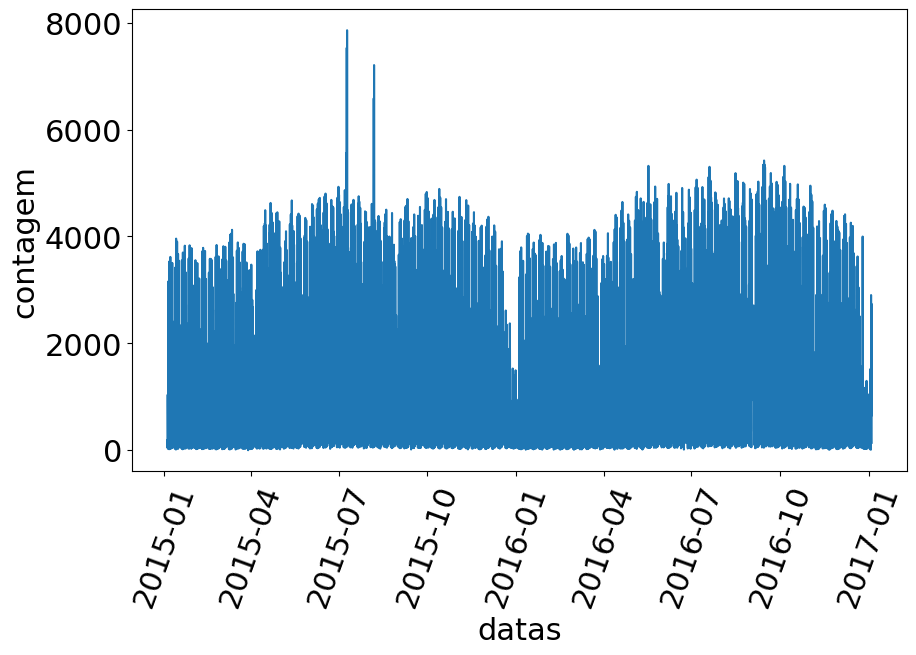

In [ ]:
sns.lineplot(x=['datas'],y=['contagem'], data=bike)
plt.xticks(rotation=70)

In [121]:
sc2 = StandardScaler()

In [122]:
sc2.fit(bike['contagem'].values.reshape(-1,1))

,copy,True
,with_mean,True
,with_std,True


In [123]:
y = sc2.transform(bike['contagem'].values.reshape(-1,1))

In [124]:
tamanho_treino = int(len(bike)*0.9) #Pegando 90% dos dados para treino
tamanho_teste = len(bike)-tamanho_treino #O resto vamos reservar para teste

In [125]:
ytreino = y[0:tamanho_treino]
yteste = y[tamanho_treino:len(bike)]

(array([16436., 16526., 16617., 16709., 16801., 16892., 16983., 17075.,
        17167.]),
 [Text(16436.0, 0, '2015-01'),
  Text(16526.0, 0, '2015-04'),
  Text(16617.0, 0, '2015-07'),
  Text(16709.0, 0, '2015-10'),
  Text(16801.0, 0, '2016-01'),
  Text(16892.0, 0, '2016-04'),
  Text(16983.0, 0, '2016-07'),
  Text(17075.0, 0, '2016-10'),
  Text(17167.0, 0, '2017-01')])

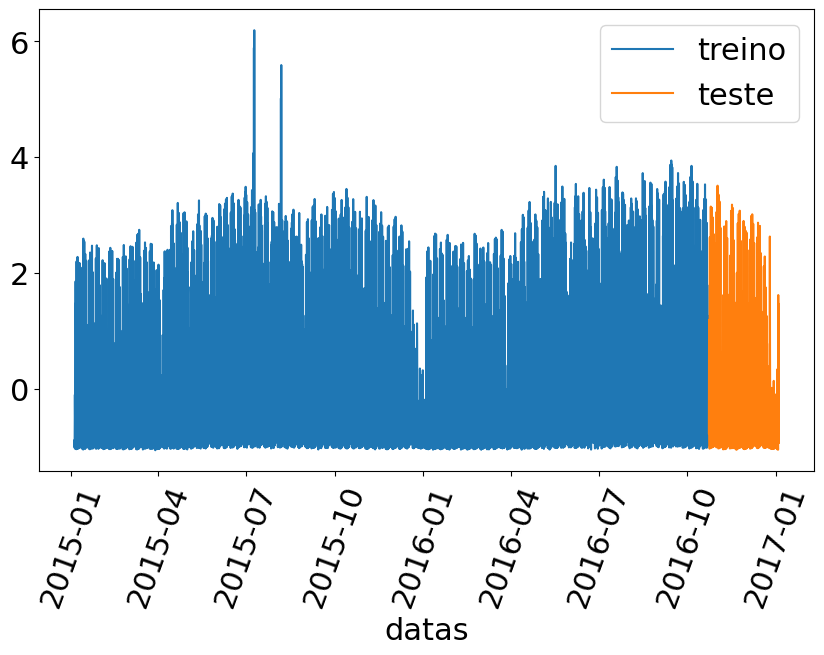

In [126]:
sns.lineplot(x='datas',y=ytreino[:,0],data=bike[0:tamanho_treino],label='treino') 
sns.lineplot(x='datas',y=yteste[:,0], data=bike[tamanho_treino:len(bike)],label='teste')
plt.xticks(rotation=70) 

In [147]:
vetor = pd.DataFrame(ytreino)[0]


In [128]:
xtreino_novo, ytreino_novo = separa_dados(vetor,10)

In [129]:
xtreino_novo[0:5]

array([[-0.88574518, -0.9262953 , -0.92998167, -0.98712048, -1.01016032,
        -1.01108192, -1.00647395, -0.9843557 , -0.93274645, -0.77607553],
       [-0.9262953 , -0.92998167, -0.98712048, -1.01016032, -1.01108192,
        -1.00647395, -0.9843557 , -0.93274645, -0.77607553, -0.56687377],
       [-0.92998167, -0.98712048, -1.01016032, -1.01108192, -1.00647395,
        -0.9843557 , -0.93274645, -0.77607553, -0.56687377, -0.38347663],
       [-0.98712048, -1.01016032, -1.01108192, -1.00647395, -0.9843557 ,
        -0.93274645, -0.77607553, -0.56687377, -0.38347663, -0.25906149],
       [-1.01016032, -1.01108192, -1.00647395, -0.9843557 , -0.93274645,
        -0.77607553, -0.56687377, -0.38347663, -0.25906149, -0.20929543]])

In [130]:
ytreino_novo[0:5]

array([-0.56687377, -0.38347663, -0.25906149, -0.20929543, -0.09593941])

In [131]:
vetor2 = pd.DataFrame(yteste)[0]

In [132]:
xteste_novo, yteste_novo = separa_dados(vetor2,10)

In [133]:
xtreino_novo = xtreino_novo.reshape((xtreino_novo.shape[0],xtreino_novo.shape[1],1))

In [134]:
xtreino_novo.shape

(15662, 10, 1)

In [135]:
xteste_novo = xteste_novo.reshape((xteste_novo.shape[0],xteste_novo.shape[1],1))

In [149]:
xteste_novo.shape

(1732, 10, 1)

### Recurrent Neural Network (LSTM) Model Definition

This code block defines the architecture of a Recurrent Neural Network (RNN) using Keras's `Sequential` API. The model is specifically designed with an LSTM layer to handle time series data.

  * **`recorrente = Sequential()`**: This initializes a `Sequential` model, which is a linear stack of layers.

  * **`recorrente.add(Input(shape=(...)))`**: This line explicitly defines the model's input layer. The `shape` is dynamically set based on the dimensions of the training data (`xtreino_novo`), corresponding to `(timesteps, features)`. This is the standard input format required by recurrent layers like LSTMs.

  * **`recorrente.add(LSTM(128))`**: This adds an LSTM (Long Short-Term Memory) layer with 128 units. The LSTM layer is the core of this model, designed to process sequences and learn temporal dependencies from the data.

  * **`recorrente.add(Dense(1))`**: This adds a final `Dense` (fully connected) layer with a single neuron. This layer serves as the output layer, consolidating the information from the LSTM layer to produce a single continuous value for the forecast.

In [ ]:
recorrente = Sequential()
recorrente.add(Input(shape=(xtreino_novo.shape[1], xtreino_novo.shape[2])))  

recorrente.add(LSTM(128))
recorrente.add(Dense(1))

In [137]:
recorrente.compile(loss='mean_squared_error',optimizer='RMSProp')
recorrente.summary()

Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                   │ (None, 128)            │        66,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 66,689 (260.50 KB)

 Trainable params: 66,689 (260.50 KB)

 Non-trainable params: 0 (0.00 B)

In [138]:
resultado = recorrente.fit(xtreino_novo,ytreino_novo,validation_data=(xteste_novo,yteste_novo),epochs=100)

Epoch 1/100
490/490 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.2862 - val_loss: 0.1170
Epoch 2/100
490/490 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0808 - val_loss: 0.0428
Epoch 3/100
490/490 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0560 - val_loss: 0.0310
Epoch 4/100
490/490 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0482 - val_loss: 0.0331
Epoch 5/100
490/490 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0443 - val_loss: 0.0358
Epoch 6/100
490/490 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0413 - val_loss: 0.0262
Epoch 7/100
490/490 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0389 - val_loss: 0.0265
Epoch 8/100
490/490 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0374 - val_loss: 0.0221
Epoch 9/100
490/490 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0357 - val_loss: 0.0243
Epoch 10/100
490/490 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0350 - val_loss: 0.0214
Epoch 11/100
490/490 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0333 - val_loss: 0.0237
Epoch 12/100
490/490 ━━━━━━━━━━━━━━━━━━━━

### Making Predictions and Visualizing the Forecast

This code block first uses the trained recurrent model (`recorrente`) to generate predictions on the unseen test data (`xteste_novo`). It then visualizes these predictions against the actual test data to evaluate the model's forecasting accuracy.

In [139]:
y_ajustado = recorrente.predict(xtreino_novo)

490/490 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


(array([16436., 16526., 16617., 16709., 16801., 16892., 16983., 17075.]),
 [Text(16436.0, 0, '2015-01'),
  Text(16526.0, 0, '2015-04'),
  Text(16617.0, 0, '2015-07'),
  Text(16709.0, 0, '2015-10'),
  Text(16801.0, 0, '2016-01'),
  Text(16892.0, 0, '2016-04'),
  Text(16983.0, 0, '2016-07'),
  Text(17075.0, 0, '2016-10')])

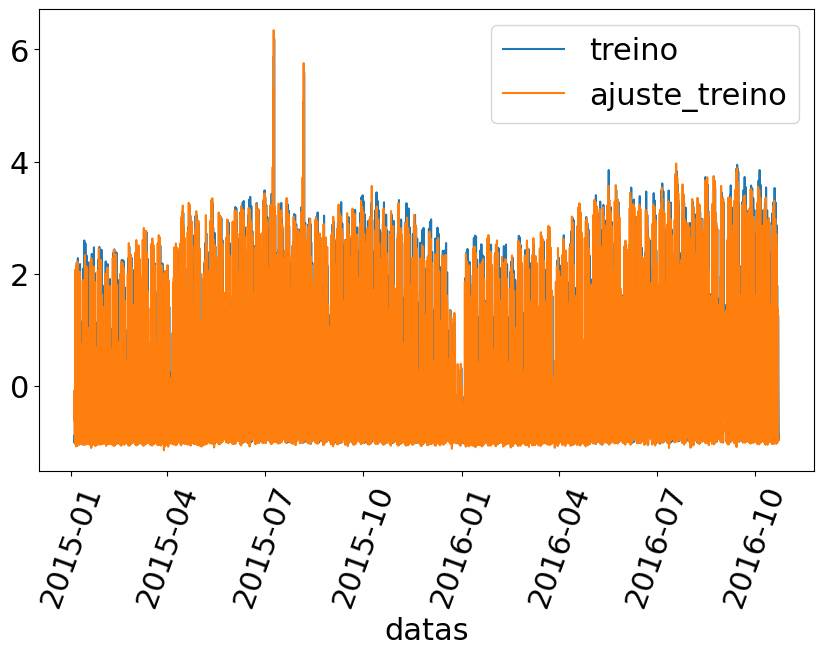

In [140]:
sns.lineplot(x='datas',y=ytreino[:,0],data=bike[0:tamanho_treino],label='treino')
sns.lineplot(x='datas',y=y_ajustado[:,0],data=bike[0:15662],label='ajuste_treino')
plt.xticks(rotation=70) 

### Making Predictions and Visualizing the Forecast

This code block first uses the trained recurrent model (`recorrente`) to generate predictions on the unseen test data (`xteste_novo`). It then visualizes these predictions against the actual test data to evaluate the model's forecasting accuracy.

In [141]:
y_predito = recorrente.predict(xteste_novo)

55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


(array([17106., 17120., 17136., 17150., 17167.]),
 [Text(17106.0, 0, '2016-11-01'),
  Text(17120.0, 0, '2016-11-15'),
  Text(17136.0, 0, '2016-12-01'),
  Text(17150.0, 0, '2016-12-15'),
  Text(17167.0, 0, '2017-01-01')])

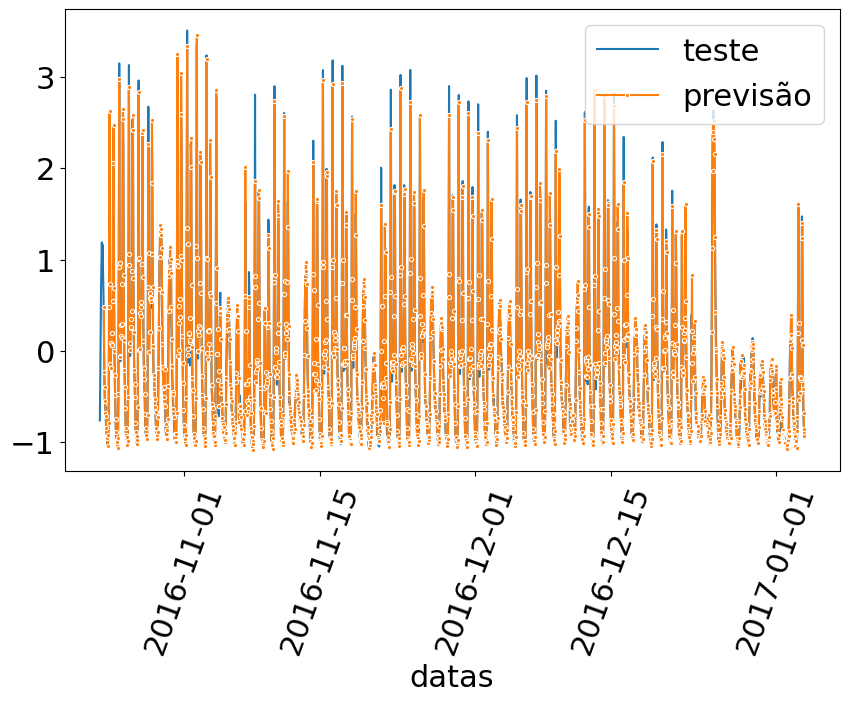

In [142]:
sns.lineplot(x='datas',y=yteste[:,0], data=bike[tamanho_treino:len(bike)],label='teste')
sns.lineplot(x='datas',y=y_predito[:,0], data=bike[tamanho_treino+10:len(bike)],marker='.',label='previsão')
plt.xticks(rotation=70) 

### Gated Recurrent Unit (GRU) Model Definition

This code defines the architecture for a recurrent neural network using a Gated Recurrent Unit (GRU) layer. GRUs, like LSTMs, are a type of recurrent layer excellent for processing sequential data but have a slightly simpler architecture.

In [153]:
recorrente_g = Sequential()
recorrente_g.add(Input(shape=(xtreino_novo.shape[1], xtreino_novo.shape[2])))  # entrada
recorrente_g.add(GRU(128))
recorrente_g.add(Dense(1))

In [154]:
recorrente_g.compile(loss='mean_squared_error',optimizer='RMSProp')
recorrente_g.summary()

Model: "sequential_14"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru_1 (GRU)                     │ (None, 128)            │        50,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 50,433 (197.00 KB)

 Trainable params: 50,433 (197.00 KB)

 Non-trainable params: 0 (0.00 B)

### Model Training with Validation Data

This code executes the training process for the compiled recurrent neural network (`recorrente_g`). The `fit` method adjusts the model's weights based on the training data over a specified number of iterations (epochs).

In [155]:
resultado2 = recorrente_g.fit(xtreino_novo, ytreino_novo,
                              validation_data=(xteste_novo, yteste_novo), epochs=100)

Epoch 1/100
490/490 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.2633 - val_loss: 0.0786
Epoch 2/100
490/490 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0691 - val_loss: 0.0384
Epoch 3/100
490/490 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0507 - val_loss: 0.0377
Epoch 4/100
490/490 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0442 - val_loss: 0.0262
Epoch 5/100
490/490 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0391 - val_loss: 0.0257
Epoch 6/100
490/490 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0366 - val_loss: 0.0259
Epoch 7/100
490/490 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0345 - val_loss: 0.0302
Epoch 8/100
490/490 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0333 - val_loss: 0.0299
Epoch 9/100
490/490 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0324 - val_loss: 0.0192
Epoch 10/100
490/490 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0317 - val_loss: 0.0213
Epoch 11/100
490/490 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0311 - val_loss: 0.0201
Epoch 12/100
490/490 ━━━━━━━━━━━━━━━━━━━━

In [156]:
y_predito2 = recorrente_g.predict(xteste_novo)

55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step


### Visualizing Forecast vs. Actual Values on Test Data

This code block generates a plot to directly compare the model's forecasted values against the actual, known values from the test set. This is a crucial step for visually assessing the real-world performance of the forecasting model.

(array([17106., 17120., 17136., 17150., 17167.]),
 [Text(17106.0, 0, '2016-11-01'),
  Text(17120.0, 0, '2016-11-15'),
  Text(17136.0, 0, '2016-12-01'),
  Text(17150.0, 0, '2016-12-15'),
  Text(17167.0, 0, '2017-01-01')])

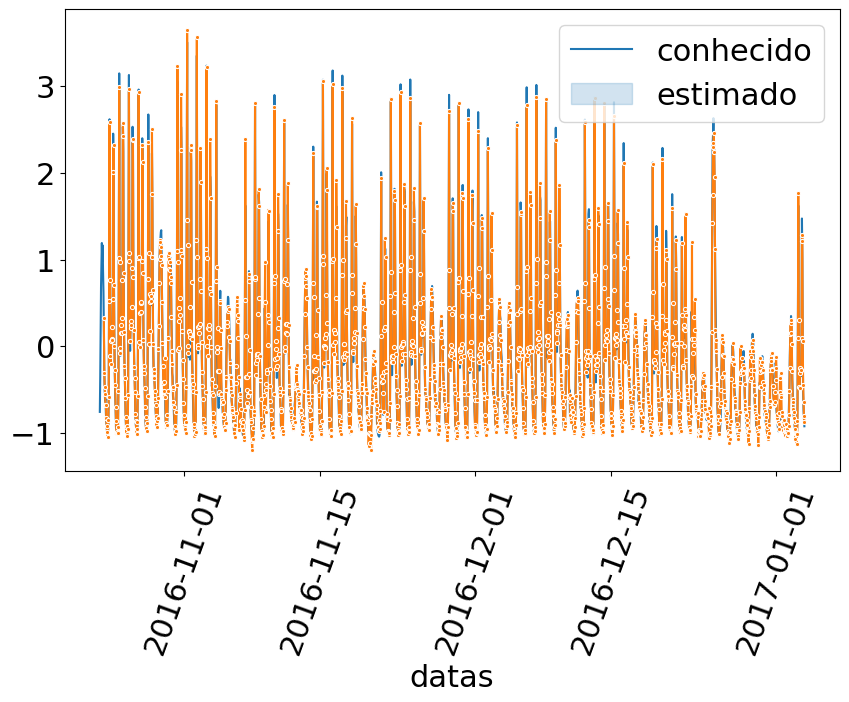

In [157]:
sns.lineplot(x='datas',y=yteste[:,0], data=bike[tamanho_treino:len(bike)])
sns.lineplot(x='datas',y=y_predito2[:,0], data=bike[tamanho_treino+10:len(bike)],marker='.')
plt.legend(['conhecido','estimado'])
plt.xticks(rotation=70) 

In [158]:
print(resultado2.history.keys())

dict_keys(['loss', 'val_loss'])


### Plotting Training & Validation Loss

This code visualizes the model's learning progress over time by plotting the loss function values for both the training and validation (test) datasets at each epoch.
By comparing these two curves, we can diagnose the model's behavior. For instance, if the training loss continues to decrease while the validation loss begins to increase, it is a clear sign of **overfitting**.

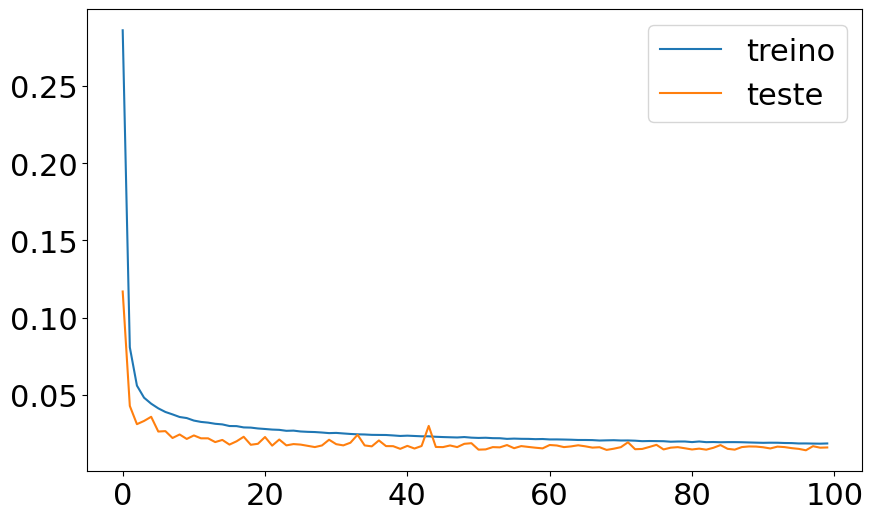

In [159]:
plt.plot(resultado.history['loss'])
plt.plot(resultado.history['val_loss'])
plt.legend(['treino','teste'])

### Plotting Training & Validation Loss

This code visualizes the model's learning progress over time by plotting the loss function values for both the training and validation (test) datasets at each epoch.
By comparing these two curves, we can diagnose the model's behavior. For instance, if the training loss continues to decrease while the validation loss begins to increase, it is a clear sign of **overfitting**.

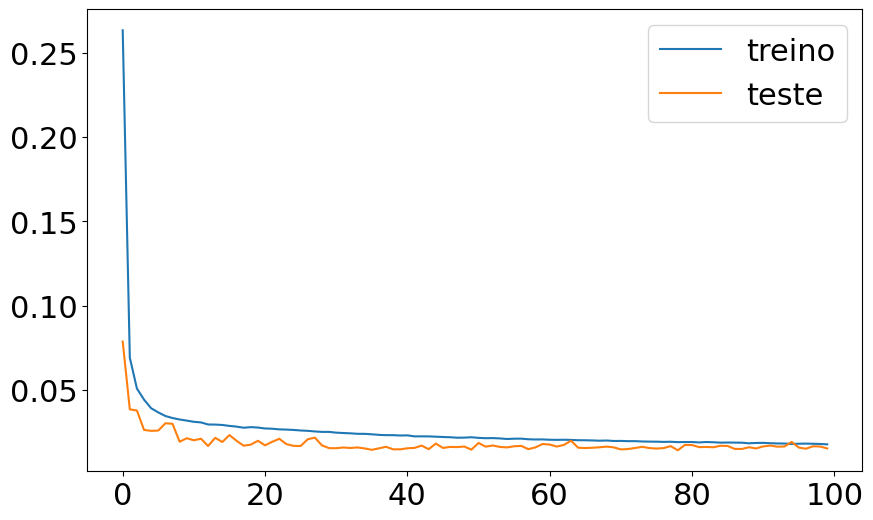

In [160]:
plt.plot(resultado2.history['loss'])
plt.plot(resultado2.history['val_loss'])
plt.legend(['treino','teste'])


### Conclusion

The LSTM model provides a powerful approach for time series forecasting, especially when dealing with data that exhibits long-term dependencies and complex patterns. While it requires more computational resources and careful tuning of hyperparameters (like the number of time steps, LSTM units, and dropout rate), its ability to model temporal dynamics often leads to superior predictive performance compared to traditional regression models.